In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
mem = pd.read_csv("https://raw.githubusercontent.com/haram4th/ablearn/main/member.csv")
tran = pd.read_csv("https://raw.githubusercontent.com/haram4th/ablearn/main/transaction.csv")

* 쇼핑몰 고객 데이터, 프로모션 쿠폰을 발행하고 사용 여부 데이터를 수집
* mem: 고객id, 최근 방문일, 사는지역, 추천여부, 주요접속채널, 쿠폰 사용 여부
* transaction: 고객id, 구매수량, 총 구매금액 정보가 있음
* 전통적 마케팅 분석 방법인 RFM 기법을 사용해 고객 데이터에서 파생변수 생성 후 분석
* Recency: 현재일 - 최근 구매일
* Frequency: 구매 빈도
* Monetary: 구매 금액

In [3]:
mem.head()

,id,recency,zip_code,is_referral,channel,conversion
0,906145,10,Surburban,0,Phone,0
1,184478,6,Rural,1,Web,0
2,394235,7,Surburban,1,Web,0
3,130152,9,Rural,1,Web,0
4,940352,2,Urban,0,Web,0


In [4]:
tran.head()

,id,num_item,total_amount
0,906145,5,34000
1,906145,1,27000
2,906145,4,33000
3,184478,4,29000
4,394235,4,33000


In [5]:
mem.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 64000 entries, 0 to 63999
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   id           64000 non-null  int64 
 1   recency      64000 non-null  int64 
 2   zip_code     64000 non-null  object
 3   is_referral  64000 non-null  int64 
 4   channel      64000 non-null  object
 5   conversion   64000 non-null  int64 
dtypes: int64(4), object(2)
memory usage: 2.9+ MB


In [6]:
mem.describe()

,id,recency,is_referral,conversion
count,64000.000000,64000.000000,64000.000000,64000.000000
mean,550694.137797,5.763734,0.502250,0.146781
std,259105.689773,3.507592,0.499999,0.353890
min,100001.000000,1.000000,0.000000,0.000000
25%,326772.000000,2.000000,0.000000,0.000000
50%,551300.000000,6.000000,1.000000,0.000000
75%,774914.500000,9.000000,1.000000,0.000000
max,999997.000000,12.000000,1.000000,1.000000


In [10]:
mem.isna().sum()

id             0
recency        0
zip_code       0
is_referral    0
channel        0
conversion     0
dtype: int64

In [24]:
mem = mem.sort_values(by='id')
mem

,id,recency,zip_code,is_referral,channel,conversion
2896,100001,6,Urban,1,Phone,0
29307,100008,3,Urban,1,Web,0
61804,100032,11,Urban,1,Phone,0
24769,100036,5,Urban,0,Web,0
50959,100070,10,Urban,1,Web,0
...,...,...,...,...,...,...
24163,999932,1,Urban,0,Multichannel,0
57544,999981,3,Rural,1,Phone,0
28800,999990,8,Rural,1,Phone,0
27164,999995,3,Surburban,1,Phone,0


In [7]:
tran.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 196836 entries, 0 to 196835
Data columns (total 3 columns):
 #   Column        Non-Null Count   Dtype
---  ------        --------------   -----
 0   id            196836 non-null  int64
 1   num_item      196836 non-null  int64
 2   total_amount  196836 non-null  int64
dtypes: int64(3)
memory usage: 4.5 MB


In [8]:
tran.describe()

,id,num_item,total_amount
count,196836.000000,196836.000000,196836.000000
mean,550557.552932,3.078365,21837.102969
std,259254.795613,1.478408,8218.005565
min,100001.000000,1.000000,8000.000000
25%,326719.000000,2.000000,15000.000000
50%,550918.000000,3.000000,22000.000000
75%,774916.000000,4.000000,29000.000000
max,999997.000000,6.000000,38000.000000


In [11]:
tran.isna().sum()

id              0
num_item        0
total_amount    0
dtype: int64

In [12]:
tran['id'].nunique()

64000

In [44]:
id_counts = tran['id'].value_counts()
id_counts

id
691067    5
720147    5
422265    5
670720    5
154620    5
         ..
881780    1
154471    1
480462    1
126129    1
156423    1
Name: count, Length: 64000, dtype: int64

In [52]:
frequency = id_counts.sort_index(ascending=True)
frequency

id
100001    2
100008    1
100032    3
100036    5
100070    4
         ..
999932    1
999981    4
999990    3
999995    1
999997    1
Name: count, Length: 64000, dtype: int64

In [53]:
print(frequency.name)

count


In [42]:
type(tran['id'].value_counts())

pandas.core.series.Series

In [28]:
idbynum_item = tran.groupby('id')['num_item'].sum()
idbynum_item

id
100001     7
100008     5
100032     8
100036    15
100070    13
          ..
999932     5
999981     8
999990     9
999995     2
999997     2
Name: num_item, Length: 64000, dtype: int64

In [29]:
idbytotal_amount = tran.groupby('id')['total_amount'].sum()
idbytotal_amount

id
100001     52000
100008     26000
100032     62000
100036    129000
100070     85000
           ...  
999932     32000
999981     91000
999990     84000
999995     27000
999997     13000
Name: total_amount, Length: 64000, dtype: int64

In [27]:
type(tran.groupby('id')['total_amount'].sum())

pandas.core.series.Series

In [31]:
tranbyid = pd.concat([idbynum_item, idbytotal_amount], axis=1)
tranbyid

,num_item,total_amount
id,,
100001,7,52000
100008,5,26000
100032,8,62000
100036,15,129000
100070,13,85000
...,...,...
999932,5,32000
999981,8,91000
999990,9,84000


* 쇼핑몰 고객 데이터, 프로모션 쿠폰을 발행하고 사용 여부 데이터를 수집
* mem: 고객id, 최근 방문일, 사는지역, 추천여부, 주요접속채널, 쿠폰 사용 여부
* transaction: 고객id, 구매수량, 총 구매금액 정보가 있음
* 전통적 마케팅 분석 방법인 RFM 기법을 사용해 고객 데이터에서 파생변수 생성 후 분석
* Recency: 현재일 - 최근 구매일
* Frequency: 구매 빈도
* Monetary: 구매 금액

In [40]:
data = pd.merge(mem, tranbyid, on='id')
data

,id,recency,zip_code,is_referral,channel,conversion,num_item,total_amount
0,100001,6,Urban,1,Phone,0,7,52000
1,100008,3,Urban,1,Web,0,5,26000
2,100032,11,Urban,1,Phone,0,8,62000
3,100036,5,Urban,0,Web,0,15,129000
4,100070,10,Urban,1,Web,0,13,85000
...,...,...,...,...,...,...,...,...
63995,999932,1,Urban,0,Multichannel,0,5,32000
63996,999981,3,Rural,1,Phone,0,8,91000
63997,999990,8,Rural,1,Phone,0,9,84000
63998,999995,3,Surburban,1,Phone,0,2,27000


In [34]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 64000 entries, 0 to 63999
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   id            64000 non-null  int64 
 1   recency       64000 non-null  int64 
 2   zip_code      64000 non-null  object
 3   is_referral   64000 non-null  int64 
 4   channel       64000 non-null  object
 5   conversion    64000 non-null  int64 
 6   num_item      64000 non-null  int64 
 7   total_amount  64000 non-null  int64 
dtypes: int64(6), object(2)
memory usage: 3.9+ MB


In [36]:
data.describe()

,id,recency,is_referral,conversion,num_item,total_amount
count,64000.000000,64000.000000,64000.000000,64000.000000,64000.000000,64000.000000
mean,550694.137797,5.763734,0.502250,0.146781,9.467703,67161.375000
std,259105.689773,3.507592,0.499999,0.353890,5.037690,33653.059354
min,100001.000000,1.000000,0.000000,0.000000,1.000000,8000.000000
25%,326772.000000,2.000000,0.000000,0.000000,5.000000,39000.000000
50%,551300.000000,6.000000,1.000000,0.000000,9.000000,66000.000000
75%,774914.500000,9.000000,1.000000,0.000000,13.000000,93000.000000
max,999997.000000,12.000000,1.000000,1.000000,28.000000,184000.000000


In [38]:
data['zip_code'].unique()

array(['Urban', 'Surburban', 'Rural'], dtype=object)

In [39]:
data['channel'].unique()

array(['Phone', 'Web', 'Multichannel'], dtype=object)

In [50]:
data = data.drop(columns=['frequency'])
data

,id,recency,zip_code,is_referral,channel,conversion,num_item,total_amount
0,100001,6,Urban,1,Phone,0,7,52000
1,100008,3,Urban,1,Web,0,5,26000
2,100032,11,Urban,1,Phone,0,8,62000
3,100036,5,Urban,0,Web,0,15,129000
4,100070,10,Urban,1,Web,0,13,85000
...,...,...,...,...,...,...,...,...
63995,999932,1,Urban,0,Multichannel,0,5,32000
63996,999981,3,Rural,1,Phone,0,8,91000
63997,999990,8,Rural,1,Phone,0,9,84000
63998,999995,3,Surburban,1,Phone,0,2,27000


In [54]:
data['count'] = frequency
data

,id,recency,zip_code,is_referral,channel,conversion,num_item,total_amount,count
0,100001,6,Urban,1,Phone,0,7,52000,NaN
1,100008,3,Urban,1,Web,0,5,26000,NaN
2,100032,11,Urban,1,Phone,0,8,62000,NaN
3,100036,5,Urban,0,Web,0,15,129000,NaN
4,100070,10,Urban,1,Web,0,13,85000,NaN
...,...,...,...,...,...,...,...,...,...
63995,999932,1,Urban,0,Multichannel,0,5,32000,NaN
63996,999981,3,Rural,1,Phone,0,8,91000,NaN
63997,999990,8,Rural,1,Phone,0,9,84000,NaN
63998,999995,3,Surburban,1,Phone,0,2,27000,NaN


In [55]:
data = data.drop(columns=['count'])
data

,id,recency,zip_code,is_referral,channel,conversion,num_item,total_amount
0,100001,6,Urban,1,Phone,0,7,52000
1,100008,3,Urban,1,Web,0,5,26000
2,100032,11,Urban,1,Phone,0,8,62000
3,100036,5,Urban,0,Web,0,15,129000
4,100070,10,Urban,1,Web,0,13,85000
...,...,...,...,...,...,...,...,...
63995,999932,1,Urban,0,Multichannel,0,5,32000
63996,999981,3,Rural,1,Phone,0,8,91000
63997,999990,8,Rural,1,Phone,0,9,84000
63998,999995,3,Surburban,1,Phone,0,2,27000


In [57]:
data['frequency'] = 'count'
data

,id,recency,zip_code,is_referral,channel,conversion,num_item,total_amount,frequency
0,100001,6,Urban,1,Phone,0,7,52000,count
1,100008,3,Urban,1,Web,0,5,26000,count
2,100032,11,Urban,1,Phone,0,8,62000,count
3,100036,5,Urban,0,Web,0,15,129000,count
4,100070,10,Urban,1,Web,0,13,85000,count
...,...,...,...,...,...,...,...,...,...
63995,999932,1,Urban,0,Multichannel,0,5,32000,count
63996,999981,3,Rural,1,Phone,0,8,91000,count
63997,999990,8,Rural,1,Phone,0,9,84000,count
63998,999995,3,Surburban,1,Phone,0,2,27000,count


In [58]:
data = data.drop(columns=['frequency'])
data

,id,recency,zip_code,is_referral,channel,conversion,num_item,total_amount
0,100001,6,Urban,1,Phone,0,7,52000
1,100008,3,Urban,1,Web,0,5,26000
2,100032,11,Urban,1,Phone,0,8,62000
3,100036,5,Urban,0,Web,0,15,129000
4,100070,10,Urban,1,Web,0,13,85000
...,...,...,...,...,...,...,...,...
63995,999932,1,Urban,0,Multichannel,0,5,32000
63996,999981,3,Rural,1,Phone,0,8,91000
63997,999990,8,Rural,1,Phone,0,9,84000
63998,999995,3,Surburban,1,Phone,0,2,27000


In [59]:
frequency

id
100001    2
100008    1
100032    3
100036    5
100070    4
         ..
999932    1
999981    4
999990    3
999995    1
999997    1
Name: count, Length: 64000, dtype: int64

In [61]:
data['frequency'] = list(frequency)
data

,id,recency,zip_code,is_referral,channel,conversion,num_item,total_amount,frequency
0,100001,6,Urban,1,Phone,0,7,52000,2
1,100008,3,Urban,1,Web,0,5,26000,1
2,100032,11,Urban,1,Phone,0,8,62000,3
3,100036,5,Urban,0,Web,0,15,129000,5
4,100070,10,Urban,1,Web,0,13,85000,4
...,...,...,...,...,...,...,...,...,...
63995,999932,1,Urban,0,Multichannel,0,5,32000,1
63996,999981,3,Rural,1,Phone,0,8,91000,4
63997,999990,8,Rural,1,Phone,0,9,84000,3
63998,999995,3,Surburban,1,Phone,0,2,27000,1


In [63]:
data = data.rename(columns={'total_amount': 'monetary'})
data

,id,recency,zip_code,is_referral,channel,conversion,num_item,monetary,frequency
0,100001,6,Urban,1,Phone,0,7,52000,2
1,100008,3,Urban,1,Web,0,5,26000,1
2,100032,11,Urban,1,Phone,0,8,62000,3
3,100036,5,Urban,0,Web,0,15,129000,5
4,100070,10,Urban,1,Web,0,13,85000,4
...,...,...,...,...,...,...,...,...,...
63995,999932,1,Urban,0,Multichannel,0,5,32000,1
63996,999981,3,Rural,1,Phone,0,8,91000,4
63997,999990,8,Rural,1,Phone,0,9,84000,3
63998,999995,3,Surburban,1,Phone,0,2,27000,1


In [64]:
data.describe()

,id,recency,is_referral,conversion,num_item,monetary,frequency
count,64000.000000,64000.000000,64000.000000,64000.000000,64000.000000,64000.000000,64000.000000
mean,550694.137797,5.763734,0.502250,0.146781,9.467703,67161.375000,3.075563
std,259105.689773,3.507592,0.499999,0.353890,5.037690,33653.059354,1.384222
min,100001.000000,1.000000,0.000000,0.000000,1.000000,8000.000000,1.000000
25%,326772.000000,2.000000,0.000000,0.000000,5.000000,39000.000000,2.000000
50%,551300.000000,6.000000,1.000000,0.000000,9.000000,66000.000000,3.000000
75%,774914.500000,9.000000,1.000000,0.000000,13.000000,93000.000000,4.000000
max,999997.000000,12.000000,1.000000,1.000000,28.000000,184000.000000,5.000000


<Axes: xlabel='zip_code'>

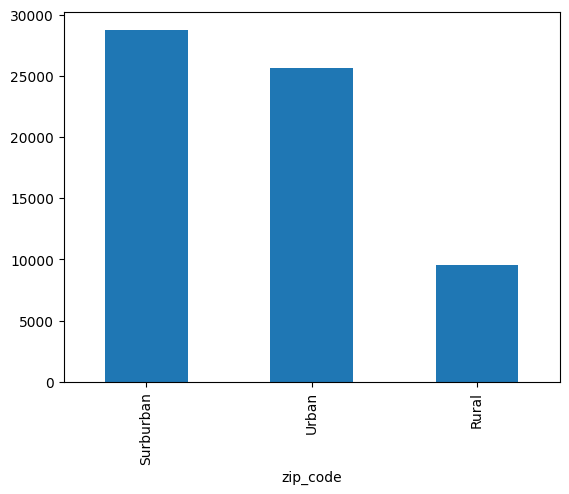

In [67]:
data['zip_code'].value_counts().plot(kind='bar')

<Axes: xlabel='channel'>

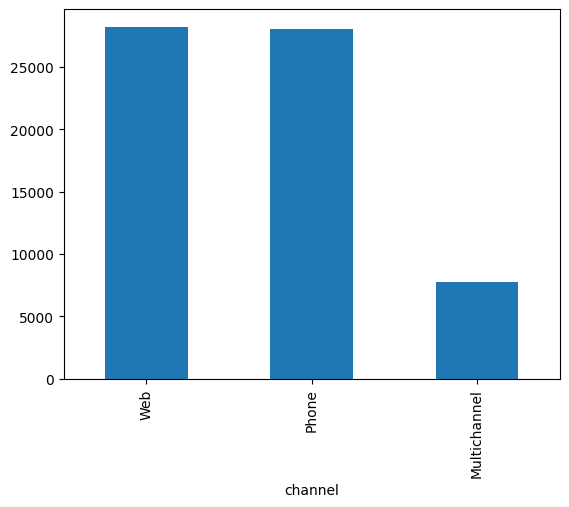

In [68]:
data['channel'].value_counts().plot(kind='bar')